In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
a = 0.3

In [ ]:
theta = np.linspace(0, np.pi, 1500)
φ = np.linspace(0, 2*np.pi, 1500)

rh = 1 + math.sqrt(1-(a**2))
rc = 1 - math.sqrt(1-(a**2))



In [ ]:
print(rh)

1.0


In [ ]:
# print(len(theta))
# print(len(φ))

In [ ]:
def r2(θ):
  return 1 - np.sqrt(1-((a**2)*(np.cos(θ))**2))

In [ ]:
def re(θ):
  return 1 + (1-((a**2)*(np.cos(θ))**2))**0.5

In [ ]:
print(re(np.pi/2))

2.0


In [ ]:
theta, φ = np.meshgrid(theta, φ)

In [ ]:
xh = np.zeros_like(len(theta))
yh = np.zeros_like(len(theta))
zh = np.zeros_like(len(theta))

xc = np.zeros_like(len(theta))
yc = np.zeros_like(len(theta))
zc = np.zeros_like(len(theta))

x2 = np.zeros_like(len(theta))
y2 = np.zeros_like(len(theta))
z2 = np.zeros_like(len(theta))

xe = np.zeros_like(len(theta))
ye = np.zeros_like(len(theta))
ze = np.zeros_like(len(theta))


In [ ]:
xh = rh*np.sin(theta)*np.cos(φ)
yh = rh*np.sin(theta)*np.sin(φ)
zh = rh*np.cos(theta)

xc = rc*np.sin(theta)*np.cos(φ)
yc = rc*np.sin(theta)*np.sin(φ)
zc = rc*np.cos(theta)

xe = re(theta)*np.sin(theta)*np.cos(φ)
ye = re(theta)*np.sin(theta)*np.sin(φ)
ze = re(theta)*np.cos(theta)

x2 = r2(theta)*np.sin(theta)*np.cos(φ)
y2 = r2(theta)*np.sin(theta)*np.sin(φ)
z2 = r2(theta)*np.cos(theta)



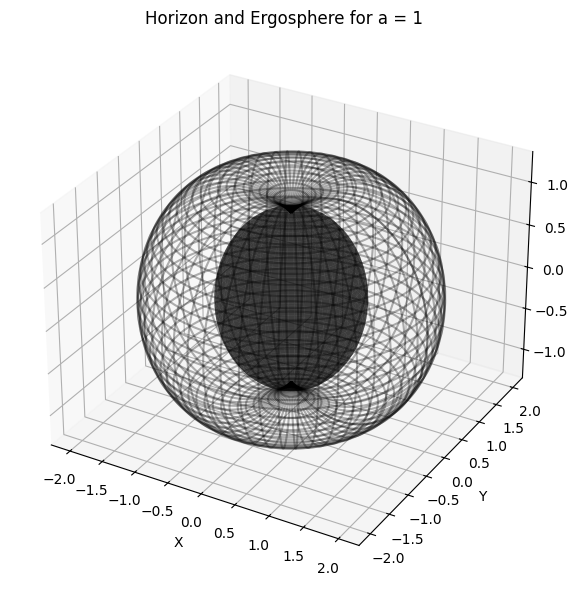

In [ ]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xh, yh, zh, color='black',  alpha=0.5)
ax.plot_wireframe(xe, ye, ze, color='red', edgecolor='k', alpha=0.3)
# ax.plot_surface(x2, y2, z2, color='blue', edgecolor='k', alpha=1)
# ax.plot_surface(xc, yc, zc, color='orange', alpha=0.7, label='Cauchy Horizon')
#ax.plot_surface(xe, ye, ze, color='dodgerblue', alpha=0.4,edgecolor='k', label='Ergosphere')

ax.set_title(f"Horizon and Ergosphere for a = {a}")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
# ax.set_box_aspect([1,1,1])
plt.tight_layout()
plt.show()

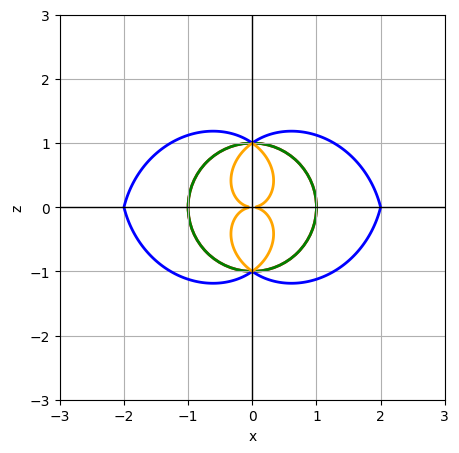

In [31]:
# Parameter
a = 1  # Change this to adjust the shape

# Create a grid for x and y
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)
Rh = 1 + math.sqrt(1-(a**2))
Rh2 = 1 - math.sqrt(1-(a**2))
# Calculate R
R = np.sqrt(X**2 + Y**2)

# Calculate the right-hand side safely (avoid division by zero)
rhs = np.where(R != 0, 1 + np.sqrt(1 - (a**2 * np.abs(Y)) / R), np.nan)
rhs2 = np.where(R != 0, 1 - np.sqrt(1 - (a**2 * np.abs(Y)) / R), np.nan)
# Define the implicit function: LHS - RHS
Z = R - rhs
Z2 = R - rhs2

# Create the plot
plt.figure(figsize=(5, 5))

# Plot the given curve
ergosphere = plt.contour(X, Y, Z, levels=[0], colors='blue', linewidths=2)
cauchy_horizon = plt.contour(X, Y, Z2, levels=[0], colors='orange', linewidths=2)

# Plot the circle with radius 2
circle = plt.Circle((0, 0), Rh, color='red', fill=False, linewidth=2, label = 'Event Horizon')
circle2 = plt.Circle((0, 0), Rh2, color='green', fill=False, linewidth=2, label = 'Cauchy Horizon')
plt.gca().add_artist(circle)
plt.gca().add_artist(circle2)

# Add axes and labels
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.gca().set_aspect('equal', adjustable='box')

# Limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.xlabel('x')
plt.ylabel('z')

# Labels and title
# plt.title(r"$\sqrt{x^2 + y^2} = 1 + \sqrt{1 - \frac{a^2|y|}{\sqrt{x^2 + y^2}}}$")
# plt.legend(['Given Curve', 'Circle r=2'])
plt.grid(True)
plt.show()